# Chapter 35 — Fractions Visualization

> **Prerequisites:** ch024 (Rational Numbers), ch034 (Ratios and Proportions)  
> **You will learn:**
> - Multiple geometric representations of fractions and why each reveals different structure
> - The Stern-Brocot tree: a binary search tree containing every positive rational exactly once
> - Mediants and how to locate a fraction in the tree
> - Farey sequences and their connection to rational approximation
> - How floating-point numbers are fractions with denominators that are powers of 2
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A fraction `p/q` is a rational number — but the symbol `p/q` is not the number, it's a *representation* of it. The same number has infinitely many representations: 1/2 = 2/4 = 3/6 = 50/100.

Visualization of fractions is not about making fractions "easier" — it's about exposing structural properties that are invisible in the symbolic form:

- **Number lines** reveal order and density
- **Area models** reveal part-whole structure
- **Stern-Brocot tree** reveals the complete enumeration of rationals
- **Farey sequences** reveal rational approximation structure
- **Binary fractions** reveal how floats work

Each visualization answers a different question. Choosing the right one is part of mathematical thinking.

**Why programmers need this:**  
Every floating-point number is a fraction with denominator 2^k for some k *(this will be made precise in ch038)*. Understanding fractions visually gives you geometric intuition for why `0.1 + 0.2 ≠ 0.3` and what "round to nearest" means geometrically.

---

## 2. Intuition & Mental Models

**The number line model:**  
Place 0 at the left and 1 at the right. Each fraction `p/q` divides this segment in a fixed position. Equivalent fractions (1/2, 2/4, 3/6) all land on the same point. The number line makes equality and order concrete.

**The Stern-Brocot tree:**  
Think of it as a binary search tree built by mediant insertion. Start with 0/1 and 1/0. The mediant of `a/b` and `c/d` is `(a+c)/(b+d)`. Insert mediants repeatedly. Every positive rational appears exactly once in the tree, in fully reduced form. The tree orders rationals by magnitude — searching for a fraction is binary search.

**Farey sequences:**  
The Farey sequence F_n contains all fractions in [0,1] with denominator ≤ n, in order. Adjacent fractions `p/q` and `p'/q'` in F_n satisfy `p'q - pq' = 1` — a surprisingly clean condition that connects fractions to determinants.

**Recall from ch024 (Rational Numbers):** We proved that the rationals are dense in the reals (between any two rationals there's another). The Stern-Brocot tree makes this constructive — you can always compute an intermediate fraction.

---

## 3. Visualization

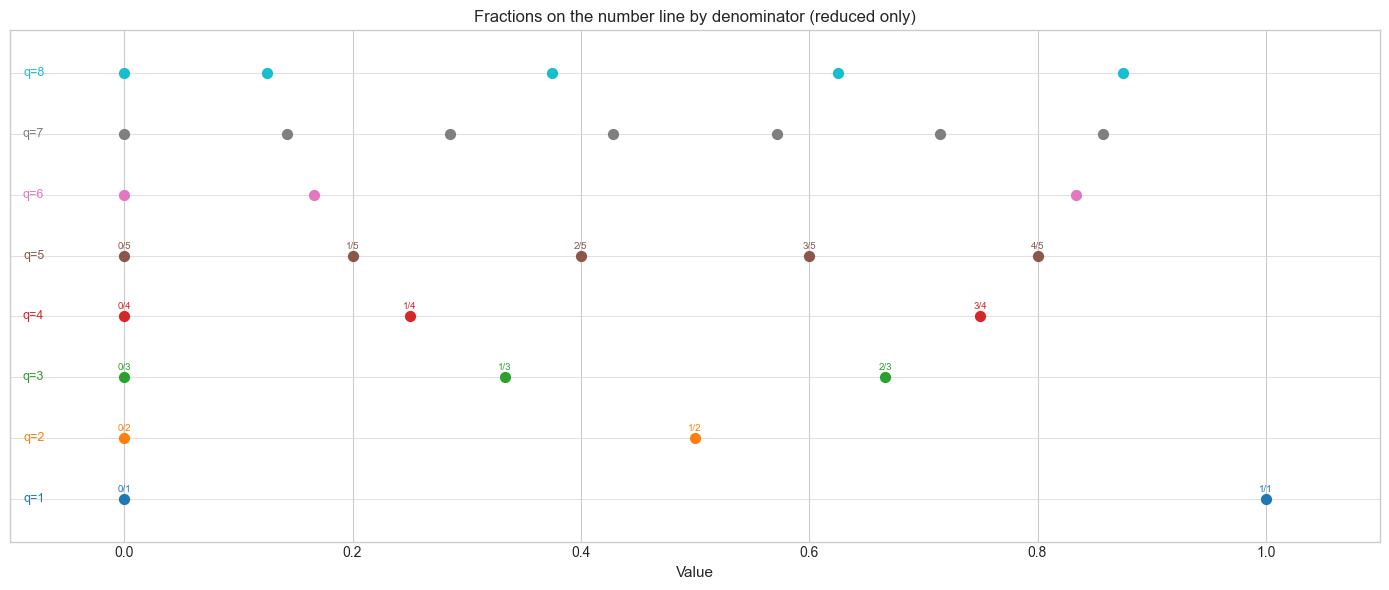

In [1]:
# --- Visualization 1: Fractions on a number line (multiple denominators) ---
import numpy as np
import matplotlib.pyplot as plt
import math

plt.style.use('seaborn-v0_8-whitegrid')

MAX_DENOM = 8   # <-- try 6, 10, 12

fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.tab10(np.linspace(0, 0.9, MAX_DENOM))

for q in range(1, MAX_DENOM + 1):
    y = q  # row position
    ax.axhline(y, color='lightgray', linewidth=0.5)
    for p in range(0, q + 1):
        x = p / q
        # Only show reduced fractions to avoid clutter
        if math.gcd(p, q) == 1 or p == 0:
            ax.scatter(x, y, color=colors[q-1], s=50, zorder=3)
            if q <= 5:  # label only small denominators
                ax.annotate(f'{p}/{q}', (x, y),
                            textcoords='offset points', xytext=(0, 5),
                            ha='center', fontsize=7, color=colors[q-1])
    ax.text(-0.07, y, f'q={q}', ha='right', va='center', fontsize=9, color=colors[q-1])

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(0.3, MAX_DENOM + 0.7)
ax.set_xlabel('Value', fontsize=11)
ax.set_yticks([])
ax.set_title(f'Fractions on the number line by denominator (reduced only)', fontsize=12)
plt.tight_layout()
plt.show()

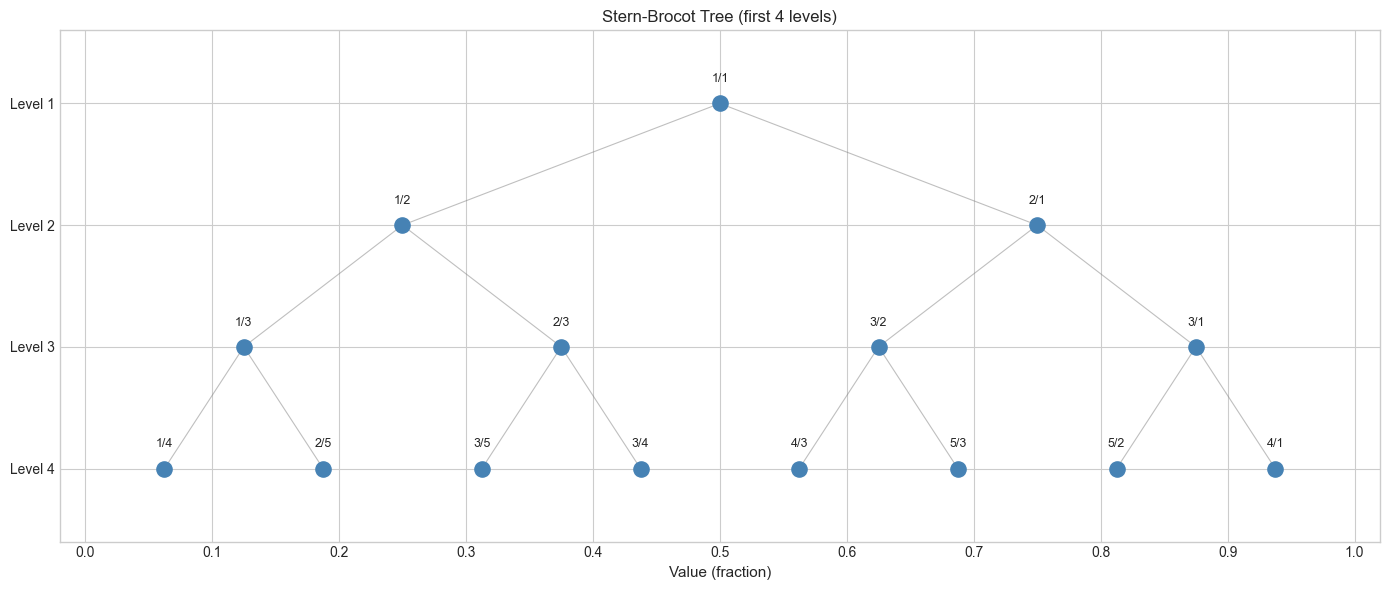

In [2]:
# --- Visualization 2: Stern-Brocot tree (first 4 levels) ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def stern_brocot_levels(n_levels):
    """
    Generate Stern-Brocot tree nodes by level.
    Returns list of levels, each level is list of (p, q) fractions.
    Uses mediant insertion between left and right bounds.
    """
    # Each node is (p, q) = mediant, with (lp, lq) left bound, (rp, rq) right bound
    # Represent as (p, q, lp, lq, rp, rq)
    tree = []
    # Level 0: just 1/1
    root = (1, 1, 0, 1, 1, 0)  # mediant of 0/1 and 1/0
    current_level = [root]
    tree.append(current_level)

    for _ in range(n_levels - 1):
        next_level = []
        for (p, q, lp, lq, rp, rq) in current_level:
            # Left child: mediant of left-bound and this node
            left_child  = (lp + p, lq + q, lp, lq, p, q)
            # Right child: mediant of this node and right-bound
            right_child = (rp + p, rq + q, p, q, rp, rq)
            next_level.extend([left_child, right_child])
        tree.append(next_level)
        current_level = next_level

    return tree


N_LEVELS = 4
tree = stern_brocot_levels(N_LEVELS)

fig, ax = plt.subplots(figsize=(14, 6))

node_positions = {}  # (p, q) -> (x, y)

for level_idx, level in enumerate(tree):
    y = N_LEVELS - level_idx
    n = len(level)
    for i, (p, q, *_) in enumerate(level):
        x = (i + 0.5) / n  # uniform spacing within level
        node_positions[(p, q, level_idx, i)] = (x, y)
        ax.scatter(x, y, color='steelblue', s=120, zorder=3)
        ax.text(x, y + 0.15, f'{p}/{q}', ha='center', va='bottom', fontsize=9)

# Draw edges: parent to children
for level_idx in range(len(tree) - 1):
    parent_level = tree[level_idx]
    child_level  = tree[level_idx + 1]
    y_parent = N_LEVELS - level_idx
    y_child  = N_LEVELS - level_idx - 1

    for pi, parent in enumerate(parent_level):
        x_parent = (pi + 0.5) / len(parent_level)
        # Two children: left at 2*pi, right at 2*pi+1
        for ci in [2 * pi, 2 * pi + 1]:
            x_child = (ci + 0.5) / len(child_level)
            ax.plot([x_parent, x_child], [y_parent, y_child],
                    'gray', linewidth=0.8, alpha=0.5)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.4, N_LEVELS + 0.6)
ax.set_yticks(range(1, N_LEVELS + 1))
ax.set_yticklabels([f'Level {N_LEVELS - i}' for i in range(N_LEVELS)])
ax.set_xlabel('Value (fraction)', fontsize=11)
ax.set_title('Stern-Brocot Tree (first 4 levels)', fontsize=12)
ax.set_xticks(np.linspace(0, 1, 11))
ax.set_xticklabels([f'{i/10:.1f}' for i in range(11)])
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Mediant:** The mediant of fractions `a/b` and `c/d` is `(a+c)/(b+d)`. Note: this is NOT addition of fractions. The mediant always lies strictly between the two fractions when `a/b < c/d`:
```
a/b < (a+c)/(b+d) < c/d
```
Proof: `(a+c)/(b+d) - a/b = (bc - ad)/(b(b+d))`. If `a/b < c/d` then `bc > ad`, so this is positive.

**Stern-Brocot property:** Every positive rational `p/q` in lowest terms appears exactly once in the Stern-Brocot tree. Searching for `p/q`:
```
Left bound: 0/1, Right bound: 1/0
While current mediant ≠ p/q:
    m = mediant(left, right)
    if p/q < m: right = m
    if p/q > m: left = m
```
This terminates because each step increases the minimum of numerator/denominator.

**Farey sequence F_n:** All fractions `p/q` with `0 ≤ p ≤ q ≤ n`, `gcd(p,q) = 1`, in ascending order.

Key property: if `a/b` and `c/d` are adjacent in F_n, then `bc - ad = 1`. This is equivalent to saying the 2×2 matrix `[[a,c],[b,d]]` has determinant ±1 — it is an integer matrix with integer inverse.

**Binary fractions:** A float with significand s and exponent e represents `s / 2^(−e)`. Every float is a fraction with denominator a power of 2. The float `0.1` decimal cannot be expressed as `k/2^n` for any integers k, n — hence the representation error *(more in ch038)*.

---

## 5. Python Implementation

In [3]:
# --- Implementation: Stern-Brocot search and Farey sequences ---
import math

def stern_brocot_search(target_p, target_q, max_steps=100):
    """
    Find path to fraction target_p/target_q in the Stern-Brocot tree.
    Returns list of 'L' (left) and 'R' (right) moves.

    Args:
        target_p, target_q: numerator and denominator (must be coprime)
        max_steps: safety limit

    Returns:
        (path as string, number of steps)
    """
    assert math.gcd(target_p, target_q) == 1, "Fraction must be in lowest terms"
    lp, lq = 0, 1   # left bound: 0/1
    rp, rq = 1, 0   # right bound: 1/0
    path = []

    for _ in range(max_steps):
        mp, mq = lp + rp, lq + rq  # mediant
        if mp == target_p and mq == target_q:
            return ''.join(path), len(path)
        elif target_p * mq < mp * target_q:  # target < mediant (cross-multiply)
            rp, rq = mp, mq
            path.append('L')
        else:
            lp, lq = mp, mq
            path.append('R')

    return None, max_steps  # not found within limit


def farey_sequence(n):
    """
    Generate Farey sequence F_n: all fractions p/q in [0,1] with q <= n, in order.

    Uses the recurrence: if a/b and c/d are adjacent in F_n, the next term
    after c/d is ((floor((b+n)/d)*c - a) / (floor((b+n)/d)*d - b))

    Args:
        n: maximum denominator

    Returns:
        list of (p, q) tuples
    """
    a, b = 0, 1  # start: 0/1
    c, d = 1, n  # second element
    sequence = [(a, b)]
    while c <= n:
        sequence.append((c, d))
        k = (n + b) // d
        a, b, c, d = c, d, k * c - a, k * d - b
    return sequence


def verify_farey_adjacency(seq):
    """Check that all adjacent pairs (a/b, c/d) satisfy bc - ad = 1."""
    violations = []
    for i in range(len(seq) - 1):
        a, b = seq[i]
        c, d = seq[i + 1]
        det = c * b - a * d
        if det != 1:
            violations.append((i, a, b, c, d, det))
    return violations


# Test Stern-Brocot search
test_fractions = [(1, 2), (3, 5), (7, 11), (355, 113), (1, 1)]
print("Stern-Brocot paths:")
for p, q in test_fractions:
    path, steps = stern_brocot_search(p, q)
    print(f"  {p}/{q}: path='{path}', depth={steps}")

# Farey sequence
F7 = farey_sequence(7)
print(f"\nFarey sequence F_7 ({len(F7)} terms):")
print([f"{p}/{q}" for p, q in F7])

violations = verify_farey_adjacency(F7)
print(f"\nAdjacency property (bc - ad = 1) violations: {len(violations)} (should be 0)")

Stern-Brocot paths:
  1/2: path='L', depth=1
  3/5: path='LRL', depth=3
  7/11: path='LRLRR', depth=5
  355/113: path='RRRLLLLLLLRRRRRRRRRRRRRRR', depth=25
  1/1: path='', depth=0

Farey sequence F_7 (19 terms):
['0/1', '1/7', '1/6', '1/5', '1/4', '2/7', '1/3', '2/5', '3/7', '1/2', '4/7', '3/5', '2/3', '5/7', '3/4', '4/5', '5/6', '6/7', '1/1']

Adjacency property (bc - ad = 1) violations: 0 (should be 0)


---

## 6. Experiments

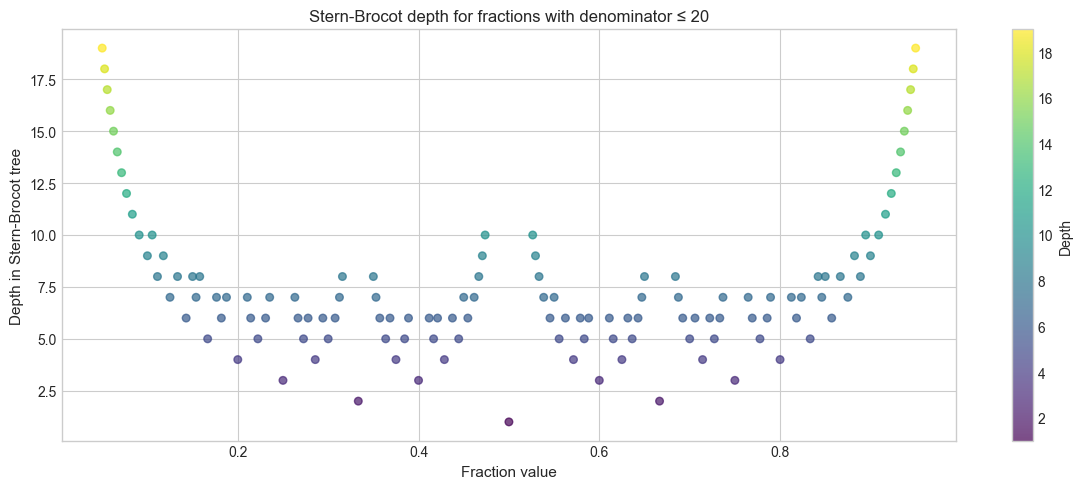

Deepest fractions:
  19/20 = 0.9500, depth=19
  1/20 = 0.0500, depth=19
  18/19 = 0.9474, depth=18
  1/19 = 0.0526, depth=18
  17/18 = 0.9444, depth=17


In [4]:
# --- Experiment 1: Depth of fractions in the Stern-Brocot tree ---
# Hypothesis: fractions with smaller denominators appear closer to the root.
#             The depth of p/q is related to the continued fraction representation of p/q.
# Try changing: the set of fractions tested.

import matplotlib.pyplot as plt

MAX_Q = 20  # test all reduced fractions with denominator up to MAX_Q

fracs = []
depths = []
values = []

for q in range(1, MAX_Q + 1):
    for p in range(1, q):
        if math.gcd(p, q) == 1:
            _, depth = stern_brocot_search(p, q)
            fracs.append((p, q))
            depths.append(depth)
            values.append(p / q)

plt.figure(figsize=(12, 5))
scatter = plt.scatter(values, depths, c=depths, cmap='viridis', s=30, alpha=0.7)
plt.colorbar(scatter, label='Depth')
plt.xlabel('Fraction value', fontsize=11)
plt.ylabel('Depth in Stern-Brocot tree', fontsize=11)
plt.title(f'Stern-Brocot depth for fractions with denominator ≤ {MAX_Q}', fontsize=12)
plt.tight_layout()
plt.show()

# Find the deepest fractions
deepest = sorted(zip(depths, fracs), reverse=True)[:5]
print("Deepest fractions:")
for d, (p, q) in deepest:
    print(f"  {p}/{q} = {p/q:.4f}, depth={d}")

In [5]:
# --- Experiment 2: Binary fractions and float representation ---
# Hypothesis: decimal fractions with non-power-of-2 denominators cannot be
#             represented exactly as IEEE 754 floats.
# Try changing: the list of test fractions.

import struct

def float_to_exact_fraction(f):
    """
    Return the exact rational value of a float64 as (numerator, denominator).
    Uses Python's float.as_integer_ratio().
    """
    return f.as_integer_ratio()


test_decimals = [0.1, 0.2, 0.3, 0.25, 0.5, 0.125, 1/3, 2/3, 0.1 + 0.2]

print(f"{'Decimal':>12}  {'Exact float value as p/q':>35}  {'Denominator is 2^k?':>20}")
print("-" * 75)
for d in test_decimals:
    p, q = float_to_exact_fraction(d)
    is_power_of_2 = (q & (q - 1)) == 0  # power of 2 iff exactly one bit set
    k = q.bit_length() - 1 if is_power_of_2 else None
    k_str = f"2^{k}" if is_power_of_2 else "NO"
    print(f"{d:>12.17f}  {p:>20}/{q:<14}  {k_str:>20}")

     Decimal             Exact float value as p/q   Denominator is 2^k?
---------------------------------------------------------------------------
0.10000000000000001      3602879701896397/36028797018963968                  2^55
0.20000000000000001      3602879701896397/18014398509481984                  2^54
0.29999999999999999      5404319552844595/18014398509481984                  2^54
0.25000000000000000                     1/4                                2^2
0.50000000000000000                     1/2                                2^1
0.12500000000000000                     1/8                                2^3
0.33333333333333331      6004799503160661/18014398509481984                  2^54
0.66666666666666663      6004799503160661/9007199254740992                  2^53
0.30000000000000004      1351079888211149/4503599627370496                  2^52


---

## 7. Exercises

**Easy 1.** Compute the mediant of 3/7 and 5/8. Verify it lies strictly between the two fractions.  
*(Expected: 8/15)*

**Easy 2.** Generate and print the Farey sequence F_5. Manually verify the adjacency property `bc - ad = 1` for the first three adjacent pairs.  

**Medium 1.** Implement a function `best_rational_approx(x, max_denom)` that finds the fraction `p/q` with `q ≤ max_denom` that best approximates the float `x`. Use Stern-Brocot search: at each step, if the mediant is closer to x, take that branch. Compare your result to Python's `fractions.Fraction(x).limit_denominator(max_denom)`.  

**Medium 2.** The continued fraction expansion of a real number `x` is `x = a_0 + 1/(a_1 + 1/(a_2 + ...))`. Implement a function `continued_fraction(x, n_terms)` and use it to show that the Stern-Brocot depth of `p/q` equals the sum of continued fraction coefficients of `p/q`.

**Hard.** Prove computationally that the Stern-Brocot tree contains every positive rational exactly once: write code that (1) generates all reduced fractions p/q with p,q ≤ N, (2) runs Stern-Brocot search for each, (3) verifies that paths are distinct, and (4) reconstructs the fraction from the path. This is a complete constructive proof of the Stern-Brocot completeness theorem.

---

## 8. Mini Project — Best Rational Approximation Finder

**Problem:** Given an irrational number (π, √2, e, the golden ratio), find the best rational approximation with denominator at most N. The Stern-Brocot tree provides a provably optimal algorithm for this — better approximations are found by following the search path longer.

**Task:** Build an interactive approximation finder that shows convergents, error, and why 355/113 is such a remarkable approximation to π.

In [ ]:
# --- Mini Project: Best Rational Approximation Finder ---
import numpy as np
import matplotlib.pyplot as plt
import math

def best_rational_approximation(x, max_denom):
    """
    Find best rational approximation to x with denominator <= max_denom.
    Uses the Stern-Brocot / mediant algorithm.

    Returns list of (p, q, error) for each 'best so far' encountered.
    """
    lp, lq = 0, 1
    rp, rq = 1, 0
    best = []  # (p, q, abs_error)
    best_err = float('inf')

    while True:
        mp, mq = lp + rp, lq + rq
        if mq > max_denom:
            break
        err = abs(mp / mq - x)
        if err < best_err:
            best_err = err
            best.append((mp, mq, err))
        if x < mp / mq:
            rp, rq = mp, mq
        else:
            lp, lq = mp, mq

    return best


targets = {
    'π':      math.pi,
    '√2':     math.sqrt(2),
    'e':      math.e,
    'φ=(1+√5)/2': (1 + math.sqrt(5)) / 2,
}

MAX_DENOM = 1000

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, x) in zip(axes.flatten(), targets.items()):
    approxs = best_rational_approximation(x, MAX_DENOM)
    denoms = [q for _, q, _ in approxs]
    errors = [e for _, _, e in approxs]

    ax.loglog(denoms, errors, 'o-', color='steelblue', markersize=5)
    ax.set_xlabel('Denominator q', fontsize=10)
    ax.set_ylabel('|p/q - x|', fontsize=10)
    ax.set_title(f'Best approximations to {name} = {x:.6f}', fontsize=11)

    # Annotate the best approximation
    best_p, best_q, best_e = approxs[-1]
    ax.annotate(f'{best_p}/{best_q}\nerr={best_e:.2e}',
                xy=(best_q, best_e), xytext=(best_q/3, best_e*50),
                arrowprops=dict(arrowstyle='->', color='crimson'), fontsize=9)

plt.tight_layout()
plt.show()

# Special focus: π approximations
pi_approxs = best_rational_approximation(math.pi, 1000)
print("\nBest approximations to π with denominator ≤ 1000:")
print(f"{'p/q':>12}  {'value':>12}  {'error':>14}")
for p, q, e in pi_approxs[-10:]:
    print(f"{p}/{q:>4}  →  {p/q:>12.10f}  error: {e:.4e}")

---

## 9. Chapter Summary & Connections

**What we covered:**
- Fractions have multiple useful visual representations — each exposes different structure
- The Stern-Brocot tree contains every positive rational exactly once, ordered by value
- Finding a fraction in the tree is binary search by mediant comparison
- Farey sequences: adjacent fractions satisfy `bc - ad = 1` (determinant condition)
- Floats are exactly binary fractions; non-power-of-2 denominators cannot be represented exactly

**Backward connection:**  
The mediant and Farey adjacency condition directly use the GCD structure and cross-multiplication from *(ch024 — Rational Numbers)* and *(ch034 — Ratios and Proportions)*.

**Forward connections:**
- The Stern-Brocot tree is a concrete preview of **binary search trees** in algorithms — the same structure with rational numbers as keys
- Binary fraction representation sets up the floating-point precision discussion in **ch038 — Precision and Floating Point Errors**
- The continued fraction connection explored in Exercise Medium 2 reappears in **ch025 — Irrational Numbers** analysis and in best rational approximation algorithms used in **ch219 — Taylor Series**

**Going deeper:** Study *continued fractions* — they provide the theoretically optimal rational approximations (the convergents) and connect fractions to the structure of real numbers in a deep way.